In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [93]:
df=pd.read_csv("task1_dataset.csv")
df

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,2.793898e+05,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,9.508975e+05,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,4.311590e+05,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,2.727301e+05,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929
...,...,...,...,...,...,...,...,...,...,...,...
1995,2025-06-18,41,70630.379654,1.525158e+06,732.884459,31,5.963429e+05,Hyderabad,Salaried,Home,300442.168194
1996,2025-06-19,41,63361.024697,3.055093e+05,546.198231,33,9.203431e+05,Delhi,Salaried,Auto,289954.022081
1997,2025-06-20,50,60798.190941,2.596022e+05,639.065695,27,6.858628e+05,Delhi,Unemployed,Home,195312.531902
1998,2025-06-21,35,56771.242421,3.296667e+05,578.375678,34,1.133484e+06,Mumbai,Unemployed,Education,263439.565538


In [94]:
df.drop("date",axis=1,inplace=True)
df.dtypes

age                   int64
income              float64
loan_amount         float64
credit_score        float64
num_transactions      int64
annual_spend        float64
city                 object
employment_type      object
loan_type            object
target              float64
dtype: object

In [95]:
df.isnull().sum()

age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [96]:
df["income"].fillna(df["income"].median(),inplace=True)
df["loan_amount"].fillna(df["loan_amount"].median(),inplace=True)
df["credit_score"].fillna(df["credit_score"].median(),inplace=True)
df["annual_spend"].fillna(df["annual_spend"].median(),inplace=True)
df.isnull().sum()

C:\Users\91998\AppData\Local\Temp\ipykernel_45208\3955794381.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income"].fillna(df["income"].median(),inplace=True)
C:\Users\91998\AppData\Local\Temp\ipykernel_45208\3955794381.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



age                 0
income              0
loan_amount         0
credit_score        0
num_transactions    0
annual_spend        0
city                0
employment_type     0
loan_type           0
target              0
dtype: int64

age                    Axes(0.125,0.653529;0.168478x0.226471)
income              Axes(0.327174,0.653529;0.168478x0.226471)
loan_amount         Axes(0.529348,0.653529;0.168478x0.226471)
credit_score        Axes(0.731522,0.653529;0.168478x0.226471)
num_transactions       Axes(0.125,0.381765;0.168478x0.226471)
annual_spend        Axes(0.327174,0.381765;0.168478x0.226471)
target              Axes(0.529348,0.381765;0.168478x0.226471)
dtype: object

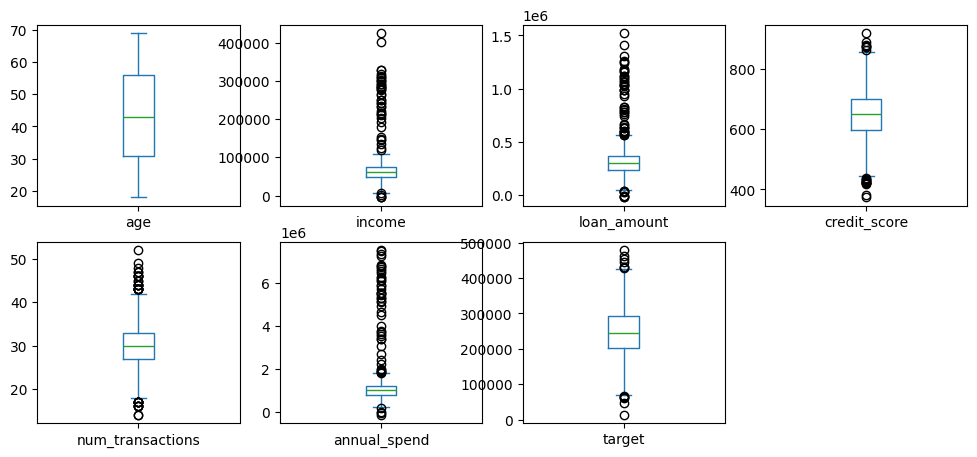

In [97]:
df.plot(kind="box",subplots=True,layout=(3,4),figsize=(12,8),sharex=False)

age                    Axes(0.125,0.653529;0.168478x0.226471)
income              Axes(0.327174,0.653529;0.168478x0.226471)
loan_amount         Axes(0.529348,0.653529;0.168478x0.226471)
credit_score        Axes(0.731522,0.653529;0.168478x0.226471)
num_transactions       Axes(0.125,0.381765;0.168478x0.226471)
annual_spend        Axes(0.327174,0.381765;0.168478x0.226471)
target              Axes(0.529348,0.381765;0.168478x0.226471)
dtype: object

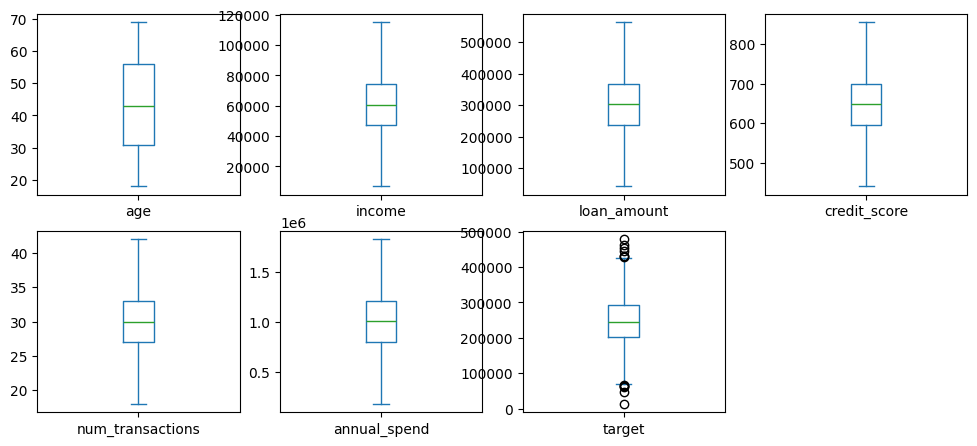

In [98]:
# iqr and outlier removal using clip in function
def out(columns):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    df[columns]=df[columns].clip(lower_bound,upper_bound)
out("income")
out("loan_amount")
out("credit_score")
out("annual_spend")
out("num_transactions")
df.plot(kind="box",subplots=True,layout=(3,4),figsize=(12,8),sharex=False)

In [99]:
df.dtypes

age                   int64
income              float64
loan_amount         float64
credit_score        float64
num_transactions      int64
annual_spend        float64
city                 object
employment_type      object
loan_type            object
target              float64
dtype: object

In [100]:
#one hot encoding using sklearn
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[["city"]])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(["city"])).astype(int)
df=pd.concat([df.drop("city",axis=1),encoded_df],axis=1)
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[["employment_type"]])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(["employment_type"])).astype(int)
df=pd.concat([df.drop("employment_type",axis=1),encoded_df],axis=1)
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[["loan_type"]])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(["loan_type"])).astype(int)
df=pd.concat([df.drop("loan_type",axis=1),encoded_df],axis=1)
df

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,294319.227774,1,0,0,0,0,0,0,0,1,1,0,0,0
1,20,47161.859481,564973.609203,716.561294,33,5.951086e+05,154516.648673,1,0,0,0,0,0,0,1,0,0,0,1,0
2,46,55234.345094,304110.307297,564.991196,28,9.989912e+05,252354.507062,0,0,1,0,0,0,0,1,0,1,0,0,0
3,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,226719.203929,0,1,0,0,0,0,0,0,1,0,0,1,0
4,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,225838.346929,0,0,1,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,41,70630.379654,564973.609203,732.884459,31,5.963429e+05,300442.168194,0,0,0,1,0,1,0,0,0,0,0,1,0
1996,41,63361.024697,305509.307595,546.198231,33,9.203431e+05,289954.022081,0,0,1,0,0,1,0,0,0,1,0,0,0
1997,50,60798.190941,259602.205191,639.065695,27,6.858628e+05,195312.531902,0,0,1,0,0,0,0,0,1,0,0,1,0
1998,35,56771.242421,329666.713399,578.375678,34,1.133484e+06,263439.565538,0,0,0,0,1,0,0,0,1,0,1,0,0


In [101]:
df.dtypes

age                                int64
income                           float64
loan_amount                      float64
credit_score                     float64
num_transactions                   int64
annual_spend                     float64
target                           float64
city_Bangalore                     int64
city_Chennai                       int64
city_Delhi                         int64
city_Hyderabad                     int64
city_Mumbai                        int64
employment_type_Salaried           int64
employment_type_Self-Employed      int64
employment_type_Student            int64
employment_type_Unemployed         int64
loan_type_Auto                     int64
loan_type_Education                int64
loan_type_Home                     int64
loan_type_Personal                 int64
dtype: object

In [102]:
skewness=df.skew()
skewness

age                             -0.013415
income                           0.166757
loan_amount                      0.160658
credit_score                    -0.007912
num_transactions                 0.098776
annual_spend                     0.227052
target                           0.030759
city_Bangalore                   1.569230
city_Chennai                     1.561041
city_Delhi                       1.399369
city_Hyderabad                   1.477866
city_Mumbai                      1.505041
employment_type_Salaried         1.134146
employment_type_Self-Employed    1.071586
employment_type_Student          1.321534
employment_type_Unemployed       1.107030
loan_type_Auto                   1.212066
loan_type_Education              1.218476
loan_type_Home                   1.039770
loan_type_Personal               1.158652
dtype: float64

In [103]:
#minmax scaling
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
numerical_cols=["income","loan_amount","credit_score","annual_spend","num_transactions"]
df[numerical_cols]=scaler.fit_transform(df[numerical_cols])
df

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,63,0.517811,0.455007,0.422850,0.541667,0.309201,294319.227774,1,0,0,0,0,0,0,0,1,1,0,0,0
1,20,0.371859,1.000000,0.664027,0.625000,0.250981,154516.648673,1,0,0,0,0,0,0,1,0,0,0,1,0
2,46,0.446187,0.502182,0.300408,0.416667,0.497654,252354.507062,0,0,1,0,0,0,0,1,0,1,0,0,0
3,52,0.625536,0.744635,0.318988,0.291667,0.315521,226719.203929,0,1,0,0,0,0,0,0,1,0,0,1,0
4,56,0.700282,0.442298,0.896897,0.666667,0.562879,225838.346929,0,0,1,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,41,0.587947,1.000000,0.703187,0.541667,0.251735,300442.168194,0,0,0,1,0,1,0,0,0,0,0,1,0
1996,41,0.521014,0.504852,0.255323,0.625000,0.449620,289954.022081,0,0,1,0,0,1,0,0,0,1,0,0,0
1997,50,0.497416,0.417245,0.478114,0.375000,0.306410,195312.531902,0,0,1,0,0,0,0,0,1,0,0,1,0
1998,35,0.460338,0.550953,0.332517,0.666667,0.579796,263439.565538,0,0,0,0,1,0,0,0,1,0,1,0,0


In [104]:
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print("knn accuracy:",knn.score(x_test,y_test))

knn accuracy: -0.0915486224459332


In [105]:
#training and testing accuracy of knn
print("knn training accuracy:",knn.score(x_train,y_train))
print("knn testing accuracy:",knn.score(x_test,y_test))

knn training accuracy: 0.2706352714609016
knn testing accuracy: -0.0915486224459332


In [106]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
print("linear regression accuracy:",lr.score(x_test,y_test))

linear regression accuracy: 0.3675020194375571


In [107]:
#training and testing accuracy
print("linear regression training accuracy:",lr.score(x_train,y_train))
print("linear regression testing accuracy:",lr.score(x_test,y_test))

linear regression training accuracy: 0.3757260560289618
linear regression testing accuracy: 0.3675020194375571


In [108]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=49)
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)
print("decision tree accuracy:",dt.score(x_test,y_test))


decision tree accuracy: -0.3414771032984394


In [109]:
#training and testing accuracy of decision tree
print("decision tree training accuracy:",dt.score(x_train,y_train))
print("decision tree testing accuracy:",dt.score(x_test,y_test))

decision tree training accuracy: 1.0
decision tree testing accuracy: -0.3414771032984394
